In [98]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/data/find_repeats_results/merged.tsv'

In [42]:
df = pl.read_csv(infpath, separator='\t')

In [43]:
df = df.with_columns(
    (
        pl.col('repeat_len').cast(pl.String) \
        + '_' \
        + pl.col('repeat_idx').cast(pl.String) \
        + '_' \
        + pl.col('rate').cast(pl.String) \
    ).alias('repeat_id')
)

In [44]:
df.head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
10000,0,0.0,"""true""",87045,97045,"""10000_0_0.0"""
10000,0,0.0,"""true""",480271,490271,"""10000_0_0.0"""
10000,0,0.0,"""pred""",87045,97045,"""10000_0_0.0"""
10000,0,0.0,"""pred""",480271,490271,"""10000_0_0.0"""
10000,0,0.01,"""true""",87045,97045,"""10000_0_0.01"""


In [45]:
true_df = df.filter(
    pl.col('value_type') == 'true'
)
pred_df = df.filter(
    pl.col('value_type') == 'pred'
)

In [46]:
true_df.shape

(8400, 7)

In [47]:
pred_df.shape

(7614, 7)

In [48]:
true_df.filter(pl.col('rate') == 0.0).head()

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
10000,0,0.0,"""true""",87045,97045,"""10000_0_0.0"""
10000,0,0.0,"""true""",480271,490271,"""10000_0_0.0"""
10000,1,0.0,"""true""",242275,252275,"""10000_1_0.0"""
10000,1,0.0,"""true""",330321,340321,"""10000_1_0.0"""
10000,10,0.0,"""true""",200740,210740,"""10000_10_0.0"""


In [49]:
all_repeat_ids = frozenset(
    true_df['repeat_id']
)

In [50]:
MAX_ERROR_BP = 10

In [51]:
repeat_id_list = list()
repeat_start_coord_list = list()
repeat_found_list = list()

for repeat_id in all_repeat_ids:
    curr_true_df = true_df.filter(pl.col('repeat_id') == repeat_id)
    curr_pred_df = pred_df.filter(pl.col('repeat_id') == repeat_id)

    for true_row in curr_true_df.to_dicts():
        curr_pred_detect_df = curr_pred_df.filter(
            (pl.col('repeat_id') == repeat_id) \
          & ( (pl.col('start_coord') - true_row['start_coord']).abs() <= MAX_ERROR_BP ) \
          & ( (pl.col('end_coord')   - true_row['end_coord']).abs() <= MAX_ERROR_BP )
        )

        found_value = 0
        if curr_pred_detect_df.shape[0] > 0:
            found_value = 1
        # end if

        repeat_id_list.append(repeat_id)
        repeat_start_coord_list.append(true_row['start_coord'])
        repeat_found_list.append(found_value)
    # end for
# end for

In [52]:
print(len(repeat_id_list))
print(len(repeat_start_coord_list))
print(len(repeat_found_list))

repeat_detect_df = pl.DataFrame({
    'repeat_id': repeat_id_list,
    'repeat_start_coord': repeat_start_coord_list,
    'repeat_detected': repeat_found_list,
})

8400
8400
8400


In [53]:
repeat_detect_df.shape

(8400, 3)

In [54]:
assert repeat_detect_df.shape[0] == true_df.shape[0]

In [55]:
repeat_detect_df = repeat_detect_df.join(
    true_df,
    on='repeat_id',
    how='inner'
).select(
    pl.col('repeat_id', 'repeat_start_coord', 'repeat_detected', 'repeat_len', 'repeat_idx', 'rate')
).unique()

In [56]:
repeat_detect_df.shape

(8400, 6)

In [57]:
repeat_detect_df.head()

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""10000_18_0.04""",160778,1,10000,18,0.04
"""200_67_0.02""",194157,1,200,67,0.02
"""3000_13_0.02""",252713,1,3000,13,0.02
"""1000_34_0.04""",190983,1,1000,34,0.04
"""1000_22_0.02""",135514,1,1000,22,0.02


In [58]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.0) & (pl.col('repeat_len') == 1000)
).sort(by='repeat_idx')

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""1000_0_0.0""",223146,1,1000,0,0.0
"""1000_0_0.0""",309121,1,1000,0,0.0
"""1000_1_0.0""",484085,1,1000,1,0.0
"""1000_1_0.0""",261068,1,1000,1,0.0
"""1000_2_0.0""",190311,1,1000,2,0.0
…,…,…,…,…,…
"""1000_97_0.0""",249847,1,1000,97,0.0
"""1000_98_0.0""",412837,1,1000,98,0.0
"""1000_98_0.0""",131199,1,1000,98,0.0


In [74]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.02) & (pl.col('repeat_len') == 10000) & (pl.col('repeat_detected') != 1)
).sort(by='repeat_idx')

repeat_id,repeat_start_coord,repeat_detected,repeat_len,repeat_idx,rate
str,i64,i64,i64,i64,f64
"""10000_84_0.02""",239243,0,10000,84,0.02
"""10000_84_0.02""",249443,0,10000,84,0.02


In [75]:
df.filter(
    (pl.col('rate') == 0.02) & (pl.col('repeat_len') == 10000) & (pl.col('repeat_idx') == 84)
).sort(by=['repeat_idx', 'value_type', 'start_coord'])

repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,repeat_id
i64,i64,f64,str,i64,i64,str
10000,84,0.02,"""pred""",239243,259443,"""10000_84_0.02"""
10000,84,0.02,"""true""",239243,249243,"""10000_84_0.02"""
10000,84,0.02,"""true""",249443,259443,"""10000_84_0.02"""


In [61]:
N_repeats = true_df.filter(
    pl.col('rate') == 0.0
).shape[0]
print('N_repeats = {}'.format(N_repeats))

per_rate_summary_df = repeat_detect_df.group_by('rate').agg(
    pl.col('repeat_detected').sum().alias('repeat_detected_count')
).sort(by=['rate'])

per_rate_summary_df = per_rate_summary_df.with_columns(
    (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
)

per_rate_summary_df.head(10)

N_repeats = 1400


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,1400,100.0
0.01,1362,97.285714
0.02,1322,94.428571
0.03,1268,90.571429
0.04,1154,82.428571
0.05,1104,78.857143


In [62]:
def get_per_rate_df(repeat_detect_df, true_df, repeat_len=200):
    N_repeats = true_df.filter(
        (pl.col('repeat_len') == repeat_len) \
        & (pl.col('rate') == 0.0)
    ).shape[0]
    print('N_repeats = {}'.format(N_repeats))
    
    result_df = repeat_detect_df.filter(
        pl.col('repeat_len') == repeat_len
    ).group_by('rate').agg(
        pl.col('repeat_detected').sum().alias('repeat_detected_count')
    ).sort(by=['rate'])
    
    result_df = result_df.with_columns(
        (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
    )

    return result_df
# end def

In [79]:
per_rate_len127_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
per_rate_len127_summary_df.head(10)

N_repeats = 200


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,200,100.0
0.01,162,81.0
0.02,124,62.0
0.03,76,38.0
0.04,20,10.0
0.05,2,1.0


In [80]:
per_rate_len200_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
per_rate_len200_summary_df.head(10)

N_repeats = 200


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,200,100.0
0.01,200,100.0
0.02,200,100.0
0.03,192,96.0
0.04,138,69.0
0.05,102,51.0


In [81]:
per_rate_len500_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
per_rate_len500_summary_df.head(10)

N_repeats = 200


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,200,100.0
0.01,200,100.0
0.02,200,100.0
0.03,200,100.0
0.04,200,100.0
0.05,200,100.0


In [82]:
per_rate_len1k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
per_rate_len1k_summary_df.head(10)

N_repeats = 200


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,200,100.0
0.01,200,100.0
0.02,200,100.0
0.03,200,100.0
0.04,200,100.0
0.05,200,100.0


In [83]:
per_rate_len10k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)
per_rate_len10k_summary_df.head(10)

N_repeats = 200


rate,repeat_detected_count,repeat_detected_percent
f64,i64,f64
0.0,200,100.0
0.01,200,100.0
0.02,198,99.0
0.03,200,100.0
0.04,198,99.0
0.05,200,100.0


<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

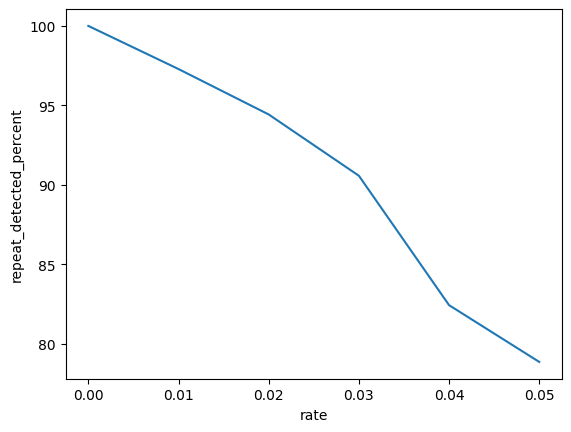

In [84]:
sns.lineplot(
    per_rate_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

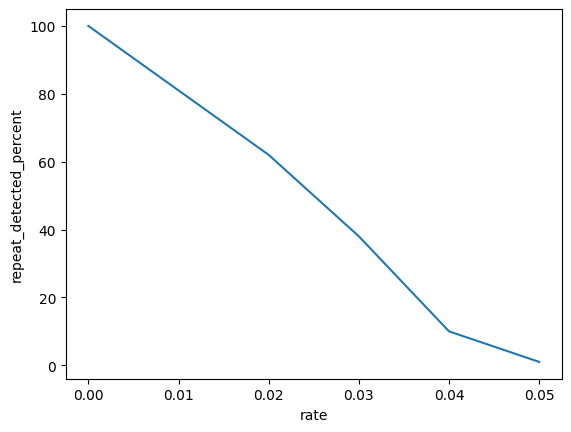

In [85]:
sns.lineplot(
    per_rate_len127_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

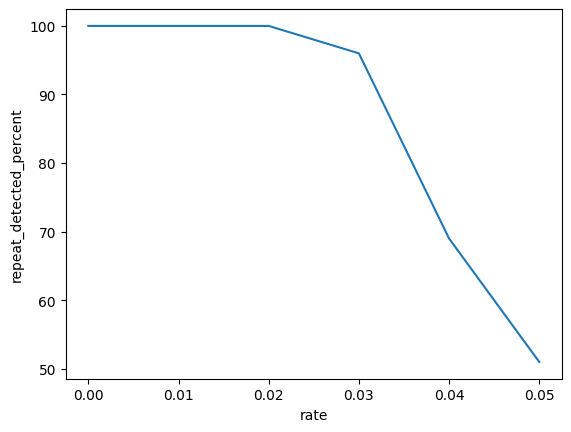

In [86]:
sns.lineplot(
    per_rate_len200_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

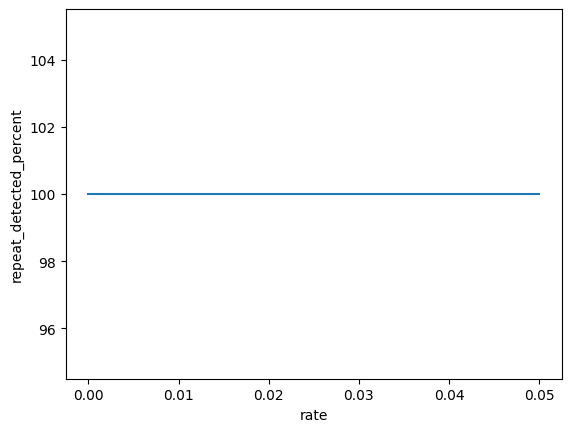

In [87]:
sns.lineplot(
    per_rate_len500_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

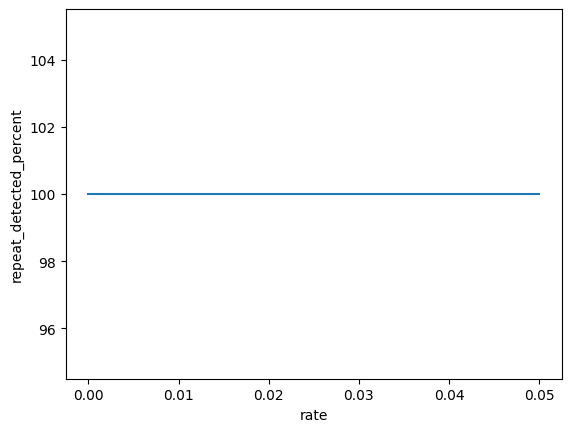

In [88]:
sns.lineplot(
    per_rate_len1k_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

<Axes: xlabel='rate', ylabel='repeat_detected_percent'>

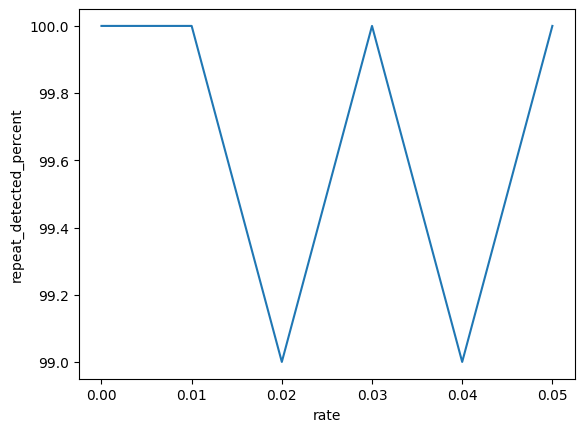

In [89]:
sns.lineplot(
    per_rate_len10k_summary_df,
    x='rate',
    y='repeat_detected_percent'
)

In [92]:
per_rate_len127_summary_df = per_rate_len127_summary_df.with_columns(pl.lit(127).alias('repeat_len'))
per_rate_len200_summary_df = per_rate_len200_summary_df.with_columns(pl.lit(200).alias('repeat_len'))
per_rate_len500_summary_df = per_rate_len500_summary_df.with_columns(pl.lit(500).alias('repeat_len'))
per_rate_len1k_summary_df = per_rate_len1k_summary_df.with_columns(pl.lit(1000).alias('repeat_len'))
per_rate_len10k_summary_df = per_rate_len10k_summary_df.with_columns(pl.lit(10000).alias('repeat_len'))

rate,repeat_detected_count,repeat_detected_percent,repeat_len
f64,i64,f64,i32
0.0,200,100.0,127
0.01,162,81.0,127
0.02,124,62.0,127
0.03,76,38.0,127
0.04,20,10.0,127


In [96]:
all_summary_df = pl.concat([
    per_rate_len127_summary_df,
    per_rate_len200_summary_df,
    per_rate_len500_summary_df,
    per_rate_len1k_summary_df,
    per_rate_len10k_summary_df,
])
all_summary_df = all_summary_df.with_columns(
    pl.col('repeat_len').cast(pl.String)
)
all_summary_df.head()

rate,repeat_detected_count,repeat_detected_percent,repeat_len
f64,i64,f64,str
0.0,200,100.0,"""127"""
0.01,162,81.0,"""127"""
0.02,124,62.0,"""127"""
0.03,76,38.0,"""127"""
0.04,20,10.0,"""127"""


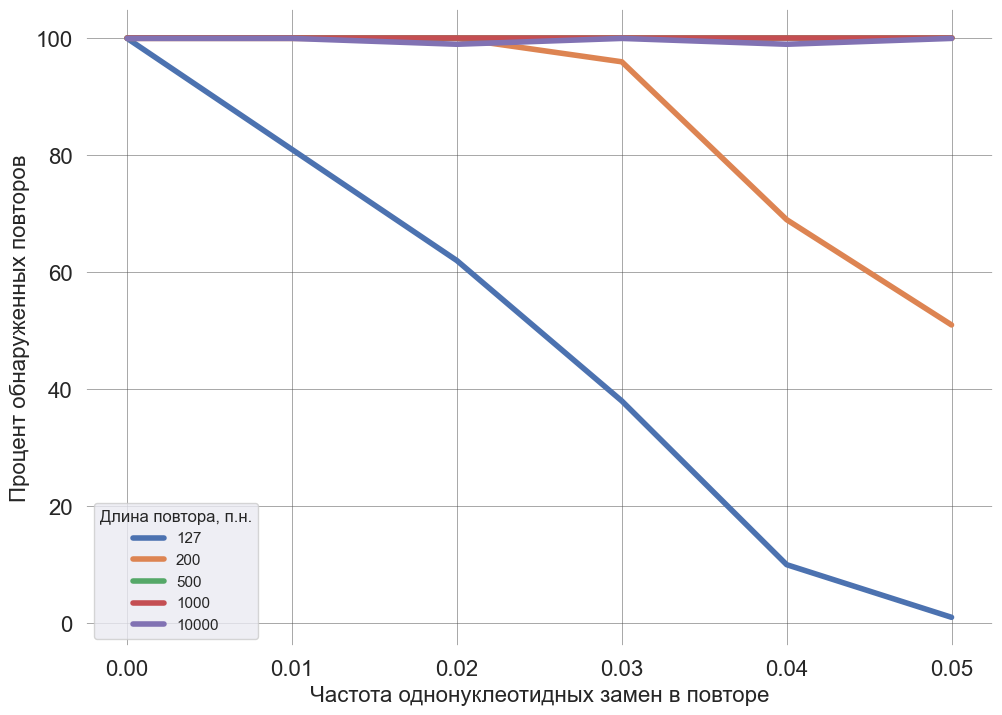

In [112]:
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_summary_df,
    x='rate',
    y='repeat_detected_percent',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Процент обнаруженных повторов', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)

ax.figure.savefig(
    '/home/cager-max/Dropbox/tmp/conf_2026_inmi/theses_sikolenko/img/repeat_detection_plot.png',
    bbox_inches='tight',
    pad_inches=0.2
)